# Sub-Genre Co-occurrence Outfit Recommendation Model

**Idea:** Instead of just learning Dress + Shoes, this model learns at the sub-genre level.

Each item gets a sub-genre label extracted from its text field:
- **Category**: "Jeans"
- **Sub-genre**: "Skinny Jeans" or "Wide Leg Jeans", etc

Co-occurrence is built on sub-genres, so "Skinny Jean" and "White Sneakers" can be specifically recommended together. This is much more detailed than Model 1.

In [55]:
#Install gdown, this lets Colab download a shared Google Drive file
!pip install gdown


In [56]:
#Our libraries
from google.colab import drive              # To access our Google Drives
from collections import defaultdict, Counter # Special dicts for grouping outfits and counting pairs
import random                               # Randomly samples outfits/items for testing
import pandas as pd                         # Works with the dataset as a DataFrame
import gdown                                # Downloads the shared dataset from Google Drive
import os
import re                                   # NEW: used to parse sub-genres from item text
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt             # These last four are used to display recommended outfits
from PIL import Image
import io
import ast


In [57]:
#Load the dataset — downloads only if not already saved in Drive.
#Make sure to give access when it asks.
from google.colab import drive
drive.mount('/content/drive')

file_id = "1D2co4zLvF30o41vYTl8o_KRrurFcGxl8"
url = f"https://drive.google.com/uc?id={file_id}"

# SAVE INSIDE GOOGLE DRIVE
output = "/content/drive/MyDrive/cleaned_polyvore.csv"

# Download only if it doesn't already exist
if not os.path.exists(output):
    gdown.download(url, output, quiet=False)

# Load dataset
df = pd.read_csv(output)
df.head()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,image,category,text,item_ID,original_category,outfit_id
0,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,Dress,tibi knit long sleeve dress,100002074_1,Day Dresses,100002074
1,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,Shoes,michael kors leather over-the-knee boots,100002074_2,Boots,100002074
2,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,Jacket,miranda coat,100002074_7,Coats,100002074
3,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,Jacket,three pocket blazer,100010727_1,Blazers,100010727
4,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,Jeans,givenchy skinny jean,100010727_2,Skinny Jeans,100010727


In [58]:
#I wrote the code with item_ID as item_id, so I'm just replacing it.
df = df.rename(columns={"item_ID": "item_id"})


In [94]:
#BUILD SUB-GENRES FROM TEXT (Here we are adding columns to or dataset using the text column)
#This is the key upgrade over Model 1.
#Instead of just using broad category labels like 'Jeans',
#we extract a more specific sub-genre label from each item's text description.
#
#How it works:
#Category  = 'Jeans'             (from the category column — same as Model 1)
#Sub-genre = 'Skinny Jeans'      (style keyword from text + category)
#
#We prioritize STYLE keywords (Skinny, Floral, Wide Leg, etc.) over generic words, so items with no color still get a useful sub-genre.
#
#Examples:
#text = 'Dark Blue Skinny Jeans from Zara'  -> 'Skinny Jeans'
#text = 'Skinny Jeans size 28'              -> 'Skinny Jeans'
#text = 'Jeans size 28'                     -> 'Jeans'  (falls back to category)

#Style keywords to look for first in text — grouped by category
STYLE_KEYWORDS = [
    # Jeans
    'Skinny', 'Slim', 'Straight', 'Wide Leg', 'Boyfriend', 'Bootcut', 'Flared', 'Cropped',
    # Dresses
    'Floral', 'Maxi', 'Mini', 'Midi', 'Wrap', 'Bodycon', 'Cocktail', 'Slip', 'Sundress',
    # Tops
    'Crop', 'Oversized', 'Fitted', 'Striped', 'Graphic', 'Lace', 'Off Shoulder',
    # Shoes
    'Heel', 'Flat', 'Platform', 'Ankle', 'Knee High', 'Block Heel', 'Stiletto', 'Wedge',
    # Outerwear
    'Denim', 'Leather', 'Trench', 'Puffer', 'Blazer', 'Bomber', 'Oversized',
    # General
    'Knit', 'Woven', 'Printed', 'Solid', 'Plaid', 'Checkered', 'Ruffle',
]

#Sort by length descending so multi-word styles like 'Wide Leg' match before 'Wide'
STYLE_KEYWORDS = sorted(STYLE_KEYWORDS, key=lambda x: -len(x))

def extract_subgenre(text, category):
    if not isinstance(text, str) or not text.strip():
        return category

    text_title = text.title()

    # Step 1: Look for a known style keyword in the text
    for style in STYLE_KEYWORDS:
        if style in text_title:
            return style + ' ' + category

    # Step 2: No style keyword found — fall back to plain category
    # (better than grabbing random words like 'Size' or '28')
    return category

# Apply to every row
df['sub_genre'] = df.apply(
    lambda row: extract_subgenre(row['text'], row['category']),
    axis=1
)

print('Sample sub-genres:')
print(df[['category', 'sub_genre', 'text']].head(50).to_string())
print(f'\nTotal unique sub-genres: {df["sub_genre"].nunique()}')


Sample sub-genres:
    category        sub_genre                                                  text
0      Dress       Knit Dress                           tibi knit long sleeve dress
1      Shoes    Leather Shoes              michael kors leather over-the-knee boots
2     Jacket           Jacket                                          miranda coat
3     Jacket    Blazer Jacket                                   three pocket blazer
4      Jeans     Skinny Jeans                                  givenchy skinny jean
5      Shirt            Shirt                         contrast trimmed cotton shirt
6      Dress            Dress            river island blue embroidered cut playsuit
7      Shoes            Shoes                                 beige crystal sandals
8      Dress            Dress                             atelier pleat shift tunic
9      Shoes    Striped Shoes        givenchy striped print pumps yellow grey black
10     Shirt            Shirt                            

In [60]:
#Splitting the data into train + test sets
#We split by outfit_id, not by individual rows.
#This prevents items from the same outfit appearing in both train and test data.
outfit_ids = df["outfit_id"].unique()

train_ids, test_ids = train_test_split(
    outfit_ids,
    test_size=0.2,
    random_state=42
)

train_df = df[df["outfit_id"].isin(train_ids)]  # Used to teach sub-genre relationships
test_df  = df[df["outfit_id"].isin(test_ids)]   # Used to evaluate the model

#This is the same as model 1


In [61]:
#Build train outfits
#outfit_id -> list of items
#Same as Model 1, but we now also store sub_genre for each item.
outfits = defaultdict(list)

for _, row in train_df.iterrows():
    outfits[row["outfit_id"]].append({
        "item_id":   row["item_id"],     #item Id label
        "category":  row["category"],    #category label
        "sub_genre": row["sub_genre"],   # NEW: sub-genre label
        "text":      row["text"]         # NEW: sub-genre label
    })

#This groups rows back into full outfits so the model can learn what sub-genres belong together.


In [62]:
#BUILD CO-OCCURRENCE MAP
#Same idea as Model 1, but now we build it on sub_genre instead of category.
#Model 1 learned:  'Jeans' <-> 'Shoes'
#Model 2 learns:   'Dark Blue Jeans' <-> 'White Sneakers'
#This makes recommendations much more specific and avoids problems like the 'Dress recommending Shirt' problem from Model 1.

co_occurrence = defaultdict(Counter)

for outfit_items in outfits.values():
    # Get the sub_genre labels for every item in this outfit
    sub_genres = [x["sub_genre"] for x in outfit_items]

    # Count every sub-genre pair inside the outfit
    for item in sub_genres:
        for other in sub_genres:
            if item != other:
                co_occurrence[item][other] += 1

# Demo: show what sub-genres are commonly paired with a jeans sub-genre
jeans_keys = [k for k in co_occurrence if "Jeans" in k]
if jeans_keys:
    print(f"Sub-genres commonly paired with '{jeans_keys[0]}':")
    print(co_occurrence[jeans_keys[0]].most_common(5))

Sub-genres commonly paired with 'Skinny Jeans':
[('Shirt', 291), ('Shoes', 237), ('Jacket', 120), ('Leather Shoes', 88), ('Tank Top', 61)]


In [63]:
# RECOMMENDATION FUNCTION
# Same structure as Model 1, but works on sub-genres.
# Input:  sub-genres the user already has, like 'Dark Blue Jeans'
# Output: sub-genres that often appear with those inputs, like 'White Sneakers'
#
# KEY IMPROVEMENT over Model 1:
# We also block any sub-genre that belongs to the same CATEGORY as the input.
# Example: if user has 'Dark Blue Jeans' (category: Jeans),
# we block ALL other Jeans sub-genres like 'Skinny Jeans', 'Wide Leg Jeans', etc.
# This is what fixes the Dress -> Shirt/Pants problem from Model 1.

# Build lookup dict ONCE here so we never scan the full dataframe inside the loop.
# subgenre_to_category['Skinny Jeans'] -> 'Jeans'  (instant lookup)
# Without this, recommend_subgenre and evaluation would run forever.

subgenre_to_category = df.drop_duplicates('sub_genre').set_index('sub_genre')['category'].to_dict()

def recommend_subgenre(input_subgenres, top_k=5):
    scores = Counter()

    # Add up co-occurrence scores for each input sub-genre
    for sg in input_subgenres:
        if sg in co_occurrence:
            scores.update(co_occurrence[sg])

    # Do not recommend something the user already provided
    for sg in input_subgenres:
        scores.pop(sg, None)

    # Block sub-genres from the same category as any input
    # Uses the lookup dict — no dataframe scanning
    input_categories = {subgenre_to_category.get(sg) for sg in input_subgenres}

    to_remove = [sg for sg in scores if subgenre_to_category.get(sg) in input_categories]
    for sg in to_remove:
        scores.pop(sg, None)

    return scores.most_common(top_k)


def recommend_items_from_subgenres(predicted_subgenres, df, n_per_subgenre=1):
    rec_items = []
    for subgenre, score in predicted_subgenres:
        candidates = df[df['sub_genre'] == subgenre]
        if len(candidates) > 0:
            item = candidates.sample(1).iloc[0]
            rec_items.append(item)
    return rec_items


In [64]:
#BUILD COMPLETE OUTFIT
#Same as Model 1, but works on sub-genres.
#
# User enters: 'Dark Blue Jeans'
# Model fills in missing outfit slots using sub-genre co-occurrence:
# -> 'White Sneakers' + 'Floral Shirt' + 'Black Jackets'

# FIX: we track which categories have already been added.
# If a recommended sub-genre belongs to a category we already have,
# we skip it so each category only appears once in the outfit.

def build_complete_outfit(input_subgenres, df, top_k=5):
    # Get more recommendations than needed so we have extras to skip if categories repeat
    recommendations = recommend_subgenre(input_subgenres, top_k=top_k)

    complete_items = []

    # Track which categories are already in the outfit
    # Start with the categories the user already provided
    used_categories = {subgenre_to_category.get(sg) for sg in input_subgenres}

    for subgenre, score in recommendations:
        category = subgenre_to_category.get(subgenre)

        # Skip if we already have an item from this category
        if category in used_categories:
            continue

        candidates = df[df['sub_genre'] == subgenre]
        if len(candidates) > 0:
            item = candidates.sample(1).iloc[0]
            complete_items.append(item)
            used_categories.add(category)  # Mark this category as used

        # Stop once we have 3 items
        if len(complete_items) == 3:
            break

    return complete_items

In [65]:
#DISPLAY THE RECOMMENDED OUTFIT
#Same as Model 1, but the title now shows sub_genre for more detail.
def show_recommendations(rec_items):
    for item in rec_items:
        image_dict = ast.literal_eval(item["image"])
        image_data = image_dict["bytes"]
        img = Image.open(io.BytesIO(image_data))

        plt.figure(figsize=(4, 4))
        plt.imshow(img)
        plt.axis("off")

        # Show sub_genre in title — more informative than Model 1's category
        plt.title(
            f'{item["sub_genre"]}\n'
            f'{item["text"]}',
            fontsize=10
        )

        plt.figtext(
            0.5, 0.01,
            f'Item ID: {item["item_id"]}\n'
            f'Outfit ID: {item["outfit_id"]}',
            ha='center', fontsize=9
        )

        plt.show()


In [66]:
#Build test outfits — same as Model 1 but also stores sub_genre.
test_outfits = defaultdict(list)

for _, row in test_df.iterrows():
    test_outfits[row["outfit_id"]].append({
        "item_id":   row["item_id"],
        "category":  row["category"],
        "sub_genre": row["sub_genre"],
        "text":      row["text"]
    })

print("Number of testing outfits:", len(test_outfits))


Number of testing outfits: 2820


In [67]:
#EVALUATION
#Same approach as Model 1: hide one item per outfit, see if the model predicts it.
#
#We evaluate at the CATEGORY level (not sub-genre level) because
#exact sub-genre matches are very hard — there are hundreds of sub-genres.
#Checking if the predicted sub-genre belongs to the right category is a fair measure of whether the model is working.
#
#Example:
# Hidden item:  'Dark Blue Jeans' (category: Jeans)
# Model predicts: 'Skinny Jeans'  (category: Jeans) -> CORRECT

correct = 0
total   = 0

for outfit_items in test_outfits.values():
    if len(outfit_items) < 2:
        continue

    hidden_item = random.choice(outfit_items)

    input_subgenres = [
        x['sub_genre']
        for x in outfit_items
        if x['item_id'] != hidden_item['item_id']
    ]

    recommendations = recommend_subgenre(input_subgenres, top_k=5)

    # Map recommended sub-genres to categories using the lookup dict — no df scan
    recommended_categories = {
        subgenre_to_category.get(sg) for sg, _ in recommendations
    }

    if hidden_item['category'] in recommended_categories:
        correct += 1

    total += 1

accuracy = correct / total if total > 0 else 0
print(f'Top-5 Category Accuracy: {accuracy:.2%}')


Top-5 Category Accuracy: 86.60%


#Now, let's make it interactive

Sample available sub-genres:
['Ankle Jeans', 'Ankle Pants', 'Ankle Shoes', 'Ankle Skirt', 'Blazer Dress', 'Blazer Jacket', 'Blazer Pants', 'Blazer Shoes', 'Block Heel Shoes', 'Bodycon Dress', 'Bodycon Jacket', 'Bodycon Jeans', 'Bodycon Pants', 'Bodycon Shorts', 'Bodycon Skirt', 'Bomber Jacket', 'Boyfriend Dress', 'Boyfriend Jacket', 'Boyfriend Jeans', 'Boyfriend Pants', 'Boyfriend Shirt', 'Boyfriend Shoes', 'Boyfriend Shorts', 'Checkered Dress', 'Checkered Jacket', 'Checkered Shirt', 'Checkered Skirt', 'Checkered Tank Top', 'Cocktail Dress', 'Cocktail Jacket']

(274 total sub-genres in dataset)

Enter a sub-genre (e.g. 'Skinny Jeans', 'Floral Dress', 'White Shoes'): Graphic Shirt 
Starting sub-genre: ['Graphic Shirt']
Number of recommendations: 3


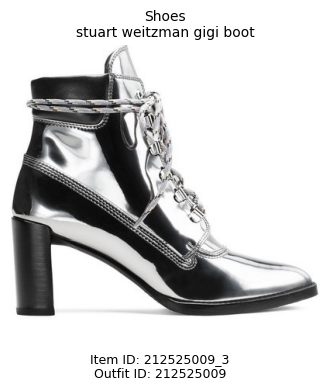

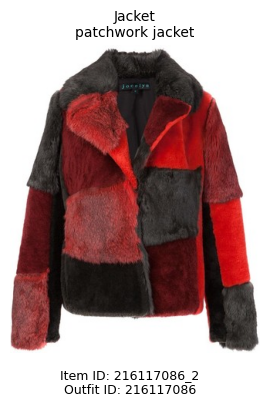

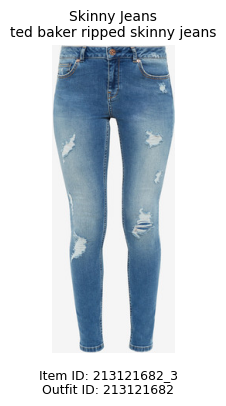

In [104]:
#USER INPUT DEMO
#Same as Model 1, but the user types a sub-genre instead of just a category.
#The model recommends matching sub-genres and shows real item images.

# Show the user what sub-genres are available
available_subgenres = sorted(df["sub_genre"].unique())
print("Sample available sub-genres:")
print(available_subgenres[:30])
print(f"\n({len(available_subgenres)} total sub-genres in dataset)")

user_input = input("\nEnter a sub-genre (e.g. 'Skinny Jeans', 'Floral Dress', 'White Shoes'): ").strip().title()

# If exact match not found, try partial match
if user_input not in df["sub_genre"].values:
    matches = [sg for sg in available_subgenres if user_input in sg]
    if matches:
        user_input = matches[0]
        print(f"Closest match found: '{user_input}'")
    else:
        print(f"No match found for '{user_input}'.")
        print("Try one of the sub-genres listed above.")
        user_input = None

if user_input:
    input_subgenres = [user_input]
    print("Starting sub-genre:", input_subgenres)

    recommended_items = build_complete_outfit(input_subgenres, df, top_k=3)

    print("Number of recommendations:", len(recommended_items))

    if len(recommended_items) == 0:
        print("No recommendations found. Try a different sub-genre.")
    else:
        show_recommendations(recommended_items)
